In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")
df = df.sort_values("fecha")

In [4]:
df["fecha"].describe()

count             77
unique            77
top       2025-01-06
freq               1
Name: fecha, dtype: object

## Pre-procesamiento

In [5]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [6]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [7]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [8]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [9]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
sector_Agropecuario_sum_true,0,0.0
badlar_ma_5,0,0.0
emae_tendencia_ciclo_lag2,0,0.0
merval_cierre_std20,0,0.0
...,...,...
act_administracion_de_donald_trump_mean_lag1,0,0.0
impacto_commodities_mean_lag1,0,0.0
emp_la nacion_mean_lag3,0,0.0
tipo_evento_otro_prop_true,0,0.0


In [10]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [11]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha

## Train-Test Split

In [12]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(61, 60)
(16, 60)


## Cross-Validation

In [13]:
# Con 63 días de entrenamiento, necesitamos ajustar para dataset pequeño
# - n_splits=3: reducido para tener suficientes datos por fold
# - test_size=8: ~2 semanas de validación por fold (ajustado al dataset pequeño)
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5

test_size = 8  # Reducido de 20 a 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)  # Reducido de 5 a 3 splits

In [14]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros MUY conservadores para ~63 observaciones y 60 features
# El problema: más features que observaciones = overfitting severo
param_distributions = {
    "n_estimators": randint(5, 50),           # Muy pocos árboles
    "max_depth": [2, 3, 4, 5],                # Árboles MUY superficiales
    "min_samples_split": randint(10, 20),     # MUY restrictivo para evitar splits
    "min_samples_leaf": randint(5, 15),       # Hojas grandes (más generalización)
    "max_features": [0.2, 0.3, 0.4, "sqrt"],  # Pocas features por split
    "bootstrap": [True],
    "max_samples": [0.5, 0.6, 0.7, 0.8],      # Submuestreo fuerte
    "min_impurity_decrease": [0.0, 0.01, 0.05, 0.1]  # Requiere ganancia mínima para split
}

In [15]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,                               # Aumentado a 40 para explorar mejor el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,                               # Más verbose para ver progreso
    refit=True,
    return_train_score=True,
    error_score=np.nan
)

In [16]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)
print("CV RMSE promedio:", -search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 2, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_impurity_decrease': 0.05, 'min_samples_leaf': 6, 'min_samples_split': 17, 'n_estimators': 5}
CV RMSE promedio: 140889.5839019604


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## Test

In [17]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


Holdout RMSE: 198124.3651
Holdout R²:   -4.3913


In [18]:
rmse_rel = rmse / y_test.mean()
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Error relativo (holdout): 9.09%


### Comparación con modelos baseline

In [20]:
# Con dataset tan pequeño, comparar contra baselines es crítico
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

# Baseline 1: Predicción con la media
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
y_pred_mean = baseline_mean.predict(X_test)
rmse_mean = root_mean_squared_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

# Baseline 2: Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Comparación
print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)
comparison = pd.DataFrame({
    'Modelo': ['Baseline (Media)', 'Ridge Regression', 'Random Forest'],
    'RMSE': [rmse_mean, rmse_ridge, rmse],
    'R²': [r2_mean, r2_ridge, r2],
    'Error Relativo': [rmse_mean/y_test.mean(), rmse_ridge/y_test.mean(), rmse/y_test.mean()]
}).sort_values('RMSE')

print(comparison.to_string(index=False))
print("="*60)

COMPARACIÓN DE MODELOS
          Modelo          RMSE          R²  Error Relativo
   Random Forest 198124.365091   -4.391283        0.090884
Baseline (Media) 259346.774175   -8.238002        0.118968
Ridge Regression 926159.497050 -116.811560        0.424851


## Análisis de resultados

### Interpretación del error CV vs Holdout

Comparar el RMSE promedio de validación cruzada con el RMSE del conjunto de holdout ayuda a evaluar:

- **Consistencia del modelo:** Si ambos errores son similares, el modelo generaliza bien
- **Overfitting:** Si CV error << Holdout error, hay sobreajuste
- **Períodos atípicos:** Si Holdout error << CV error, el período de test fue más predecible

### Evaluación del R² y error relativo

**Interpretación del R²:**
- R² > 0: El modelo tiene capacidad predictiva
- R² cercano a 0: El modelo apenas supera a predecir la media
- R² < 0: El modelo es peor que predecir la media constantemente

**Error relativo:**
- Contexto importante: El MERVAL es un índice volátil con fluctuaciones impredecibles
- Comparar siempre con modelos baseline (media, último valor, regresión lineal simple)

In [21]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

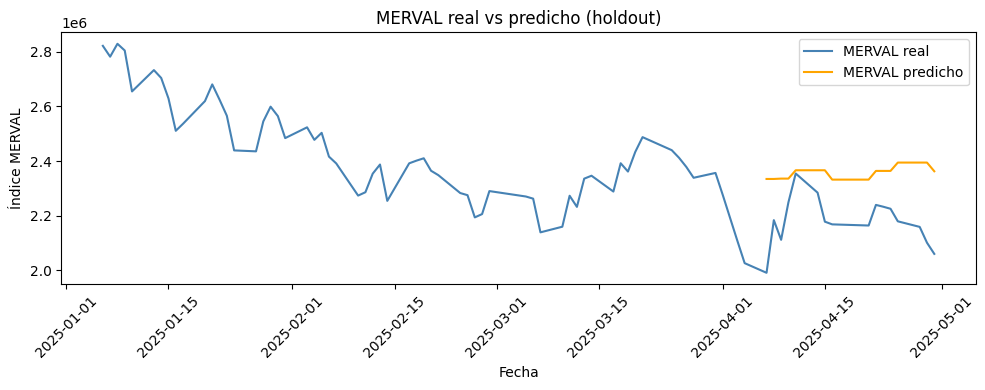

In [22]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


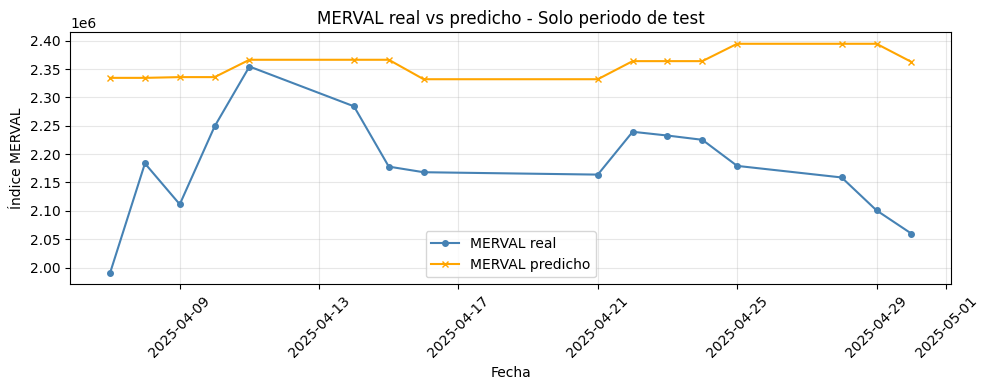

In [23]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

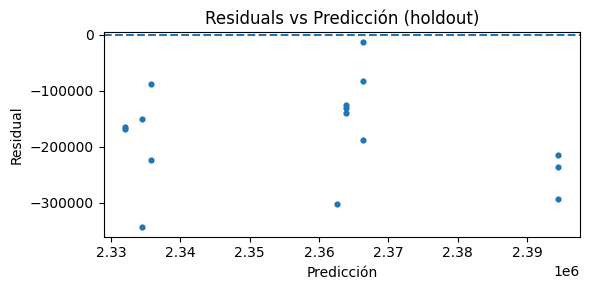

In [24]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


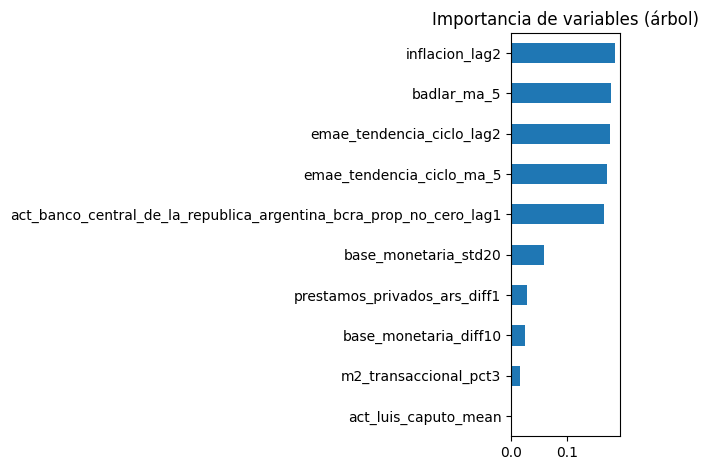

In [25]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()
